# Trying to find an appropriate k-curve to use for N = 2 ** 40

- Stretch out 2**16 k-curves
- curve-fit current 2**40 curve 

## Imports

In [43]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from math import log, e, pi, sqrt
from statistics import NormalDist
from scipy.stats import norm
from decimal import Decimal, getcontext

# Set precision to 50 decimal places to prevent catastrophic cancellation
getcontext().prec = 50

## Constants and Helper Functions

In [44]:
N = 2 ** 40
p = 1 - e ** (-2)
alpha = 0.95
t = 10000

In [45]:
## use formula to calculate vanilla m_t for t=10000

# calculate m_0 
def calculate_m0(N, t, alpha):
    mttarget = (2 * N) / (t + 2)
    return (alpha * mttarget) / (1 - alpha)

def calculate_vanilla_mt_formula(N, t, alpha):
    m_0 = calculate_m0(N, t, alpha)
    mt = (2 * N) / (t + ((2 * N)/ m_0))
    return mt



In [46]:
def get_mean(N, m):
    # Convert to Decimal for high-precision arithmetic
    N_dec = Decimal(N)
    m_dec = Decimal(m)
    return N_dec * (1 - (1 - 1/N_dec) ** m_dec)

def get_variance(N, m):
    N_dec = Decimal(N)
    m_dec = Decimal(m)
    
    E1 = (1 - 1 / N_dec) ** m_dec
    E2 = (1 - 2 / N_dec) ** m_dec

    # The precision here prevents the result from flipping to a negative float
    variance = N_dec * ((N_dec - 1) * E2 + E1 - N_dec * (E1 ** 2))
    
    # Return 0 if variance is effectively zero but technically negative due to precision
    return max(Decimal(0), variance)

def approximate_next_col(N, m, k=1):
    mean = get_mean(N, m)
    variance = get_variance(N, m)
    
    # Calculate the standard deviation using Decimal's sqrt method
    std_dev = variance.sqrt()

    # NormalDist and pi are standard floats; we convert back to float for the final step
    # as inv_cdf expects a float input.
    z_score = NormalDist().inv_cdf((k - pi / 8) / (k - pi / 4 + 1))
    
    return float(mean) + z_score * float(std_dev)

def calculate_m0_decimal(N, t, alpha):
    N_dec = Decimal(N)
    t_dec = Decimal(t)
    alpha_dec = Decimal(alpha)
    mttarget = (2 * N_dec) / (t_dec + 2)
    return (alpha_dec * mttarget) / (1 - alpha_dec)

def approximate_cherry(N, t, alpha, kjs):
    m_0 = calculate_m0_decimal(N, t, alpha)
    m = m_0
    m_val = [float(m_0)] # Store as floats for easier printing/plotting
    
    for i in range(t):
        # We pass m as the current Decimal value to maintain precision across iterations
        m = approximate_next_col(N, m, k=kjs[i])
        m_val.append(m)
        
    return m, m_val

## Stretch out 2**16 curve
- scale x values but keep y same
  - see what endpoints approximation gives
  - calculate the cost of this 
  - calculate the cost of a vanilla table 
  

## Plot original k-curve to visualise

Last point of curve: 80 3696.4004838048336


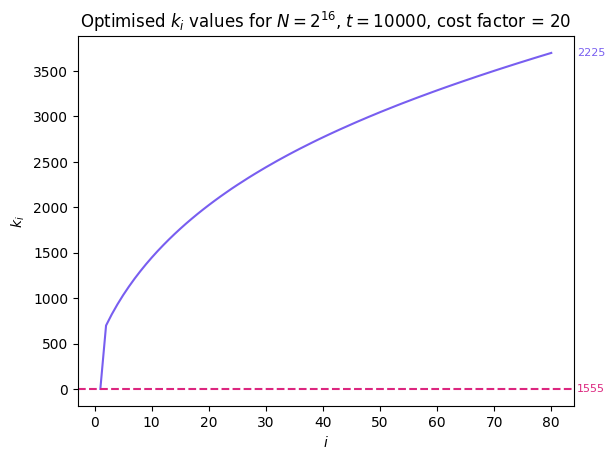

In [47]:
## import in data for 2**16
with open("data/cherry_N_16_different_alpha_0.5_0.95_optimisation_results.pkl", 'rb') as f:
    result = pickle.load(f)

kjs_16, m_0_16, final_cost_16, m_values_16 = result[-1]

## plot the optimised k_i values
# plot kjs
# kjs is 80 long, so x axis goes from 1 to 80
x_values = list(range(1, len(kjs_16) + 1))


plt.plot(x_values, kjs_16, color='#785EF0', label='Optimised $k_i$ values')
plt.xlabel('$i$')
plt.ylabel('$k_i$')

## print coords of last point
print("Last point of curve:", x_values[-1], kjs_16[-1])

# label mt at the end of the plot, not an arrow, just text
mt = m_values_16[-1]
y = kjs_16[-1]

plt.annotate(round(mt),
             xy = (x_values[-1]+3, y),   # place text outside box in line with end of curve
             xytext = (6, 0),
             color = '#785EF0',
             textcoords = 'offset points',
             size=8,
             va='center')

# plot vanilla m_t as a horizontal line at y=1
vanilla_mt = calculate_vanilla_mt_formula(2**16, 80, alpha)
plt.axhline(y=1, color='#DC267F', linestyle='--', label='Vanilla cherry-picks')

# annotate vanilla m_t line
plt.annotate(round(vanilla_mt),
             xy = (x_values[-1]+3, 1),   # place text outside box in line with end of curve
             xytext = (6, 0),
             color = '#DC267F',
             textcoords = 'offset points',
             size=8,
             va='center')



plt.title('Optimised $k_i$ values for $N=2^{16}$, $t=10000$, cost factor = 20')
plt.show()


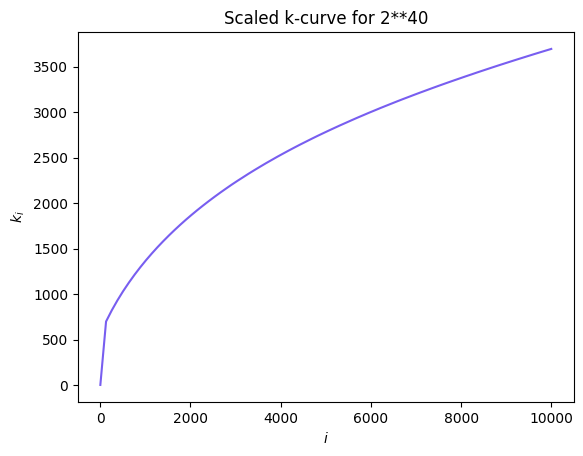

10000


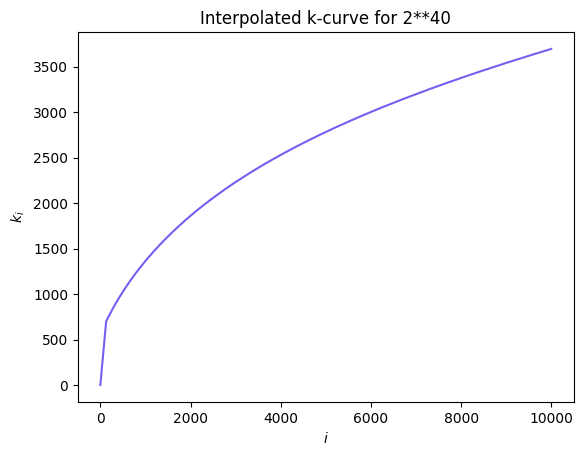

In [ ]:
# Assuming kjs_16 has 80 elements
num_old_points = len(kjs_16) # 80
num_new_points = 10000

# Map indices 0 to 79 to the range 1 to 10000
new_x = [1 + i * (num_new_points - 1) / (num_old_points - 1) for i in range(num_old_points)]
plt.plot(new_x, kjs_16, color='#785EF0', label='Optimised $k_i$ values')
plt.xlabel('$i$')
plt.ylabel('$k_i$')
plt.title('Scaled k-curve for 2**40')
plt.show()

# Original x-coordinates (1 to 10000 spread across 80 points)
old_indices = np.linspace(1, 10000, 80) 

# New x-coordinates (every integer from 1 to 10000)
new_indices = np.arange(1, 10001)

# Interpolate
kjs_40 = np.interp(new_indices, old_indices, kjs_16).tolist()

print(len(kjs_40)) # 10000

plt.plot(kjs_40, color='#785EF0', label='Optimised $k_i$ values')
plt.xlabel('$i$')
plt.ylabel('$k_i$')
plt.title('Interpolated k-curve for 2**40')
plt.show()

~ 211507744.0651 endpoints
vanilla ~ 208885303.6881098 endpoints

In [54]:
## How much does this new curve give us?
try:
    mt, m_vals = approximate_cherry(N, t, alpha, kjs_40)
    print(f"Success! Approximate cherry m_t for N = 2**40: {mt:.4f}")
except ValueError as e:
    print(f"Error encountered: {e}")

mt, m_val = approximate_cherry(N, t, alpha, kjs_40)
print("Approximate cherry m_t for N = 2**40, t=10000:", mt)

# check that for all items in m_val, the current item is bigger than the next item, if not print the index where this happens
for i in range(len(m_val)-1):
    if m_val[i] < m_val[i+1]:
        print("Index where m_i exceeds m_(i+1):", i)
        break

Success! Approximate cherry m_t for N = 2**40: 211507744.0651
Approximate cherry m_t for N = 2**40, t=10000: 211507744.06513432


## 2**40 eps = 100,000 --- curve fitted
~ 210863140.2103 endpoints

Success! Approximate cherry m_t for N = 2**40: 210863140.2103
Approximate vanilla m_t for N = 2**40, t=10000: 208885303.6881098
Success! Approximate cherry m_t for N = 2**40: 209657928.2458
Optimised m_t for t=10000: 222850214.6760254
Vanilla m_t for t=10000: 208905120.2262377


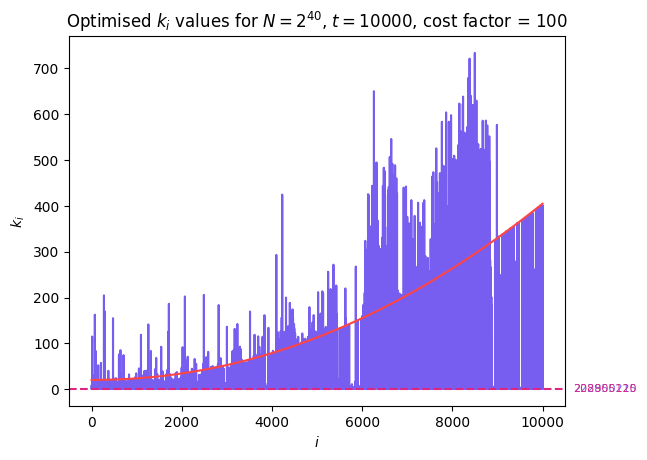

In [62]:
with open('data/N_40_alpha_0.95_cost_5_t_10000_eps_100000_optimised_kjs.pkl', 'rb') as f:
    result = pickle.load(f)

kjs_ada, m_0_ada, final_cost_ada, m_values_ada = result

def power_law(x, a, b, c):
    return a * (x + 1) ** b + c  # +1 avoids x=0 issues

# plot the fitted power law curve
x_fit = np.arange(len(kjs_ada))
# adjust third parameter c
a = 0.00000235828104
b = 2.05290278
c = 20.6085624
popt = [a, b, c]

y_fit = power_law(x_fit, *popt)

try:
    mt, m_vals = approximate_cherry(N, t, alpha, y_fit)
    print(f"Success! Approximate cherry m_t for N = 2**40: {mt:.4f}")
except ValueError as e:
    print(f"Error encountered: {e}")

mt, m_val = approximate_cherry(N, t, alpha, [1 for _ in range(10000)])
print("Approximate vanilla m_t for N = 2**40, t=10000:", mt)

# check that for all items in m_val, the current item is bigger than the next item, if not print the index where this happens
for i in range(len(m_vals)-1):
    if m_vals[i] < m_vals[i+1]:
        print("Index where m_i exceeds m_(i+1):", i)
        break

try:
    mt, m_vals = approximate_cherry(N, t, alpha, kjs_ada)
    print(f"Success! Approximate cherry m_t for N = 2**40: {mt:.4f}")
except ValueError as e:
    print(f"Error encountered: {e}")

# plot kjs
plt.plot(kjs_ada, color='#785EF0', label='Optimised $k_i$ values')
plt.xlabel('$i$')
plt.ylabel('$k_i$')

# label mt at the end of the plot, not an arrow, just text
mt = m_values_ada[-1]
y = kjs_ada[-1]
print("Optimised m_t for t=10000:", mt)

plt.annotate(round(mt),
             xy = (len(kjs_ada)+500, y),   # place text outside box in line with end of curve
             xytext = (6, 0),
             color = '#785EF0',
             textcoords = 'offset points',
             size=8,
             va='center')

# plot vanilla m_t as a horizontal line at y=1
vanilla_mt = calculate_vanilla_mt_formula(N, t, alpha)
print("Vanilla m_t for t=10000:", vanilla_mt)
plt.axhline(y=1, color='#DC267F', linestyle='--', label='Vanilla cherry-picks')

# annotate vanilla m_t line
plt.annotate(round(vanilla_mt),
             xy = (len(kjs_ada)+500, 1),   # place text outside box in line with end of curve
             xytext = (6, 0),
             color = '#DC267F',
             textcoords = 'offset points',
             size=8,
             va='center')

# plot the fitted power law curve
x_fit = np.arange(len(kjs_ada))
y_fit = power_law(x_fit, *popt)
plt.plot(x_fit, y_fit, color='#FF4444', label='Fitted power law curve')


plt.title('Optimised $k_i$ values for $N=2^{40}$, $t=10000$, cost factor = 100')
plt.show()

In [65]:
print(len(y_fit))
# store y_fit for k_curve
with open("data/N40_kcurve.pkl", 'wb') as f:
    pickle.dump(y_fit, f)

10000


## eps = 10,000
209568895.9253 points

Success! Approximate cherry m_t for N = 2**40: 209568895.9253
Optimised m_t for t=10000: 221724278.4552002
Vanilla m_t for t=10000: 208905120.2262377


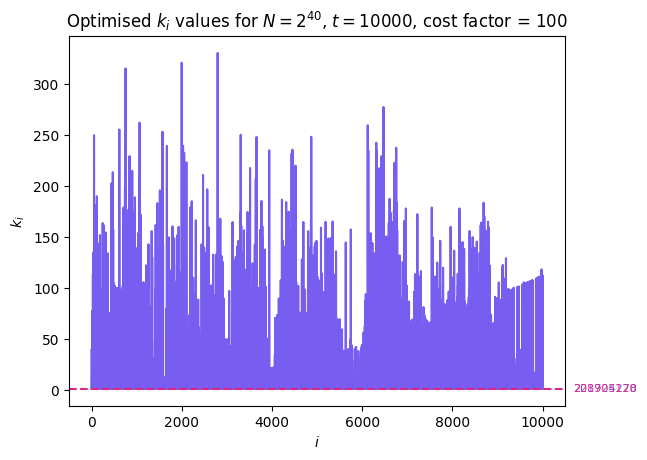

In [59]:
with open('data/N_40_alpha_0.95_cost_5_t_10000_eps_10000_optimised_kjs.pkl', 'rb') as f:
    result = pickle.load(f)

kjs_ada, m_0_ada, final_cost_ada, m_values_ada = result

try:
    mt, m_vals = approximate_cherry(N, t, alpha, kjs_ada)
    print(f"Success! Approximate cherry m_t for N = 2**40: {mt:.4f}")
except ValueError as e:
    print(f"Error encountered: {e}")

# check that for all items in m_val, the current item is bigger than the next item, if not print the index where this happens
for i in range(len(m_vals)-1):
    if m_vals[i] < m_vals[i+1]:
        print("Index where m_i exceeds m_(i+1):", i)
        break

# plot kjs
plt.plot(kjs_ada, color='#785EF0', label='Optimised $k_i$ values')
plt.xlabel('$i$')
plt.ylabel('$k_i$')

# label mt at the end of the plot, not an arrow, just text
mt = m_values_ada[-1]
y = kjs_ada[-1]
print("Optimised m_t for t=10000:", mt)

plt.annotate(round(mt),
             xy = (len(kjs_ada)+500, y),   # place text outside box in line with end of curve
             xytext = (6, 0),
             color = '#785EF0',
             textcoords = 'offset points',
             size=8,
             va='center')

# plot vanilla m_t as a horizontal line at y=1
vanilla_mt = calculate_vanilla_mt_formula(N, t, alpha)
print("Vanilla m_t for t=10000:", vanilla_mt)
plt.axhline(y=1, color='#DC267F', linestyle='--', label='Vanilla cherry-picks')

# annotate vanilla m_t line
plt.annotate(round(vanilla_mt),
             xy = (len(kjs_ada)+500, 1),   # place text outside box in line with end of curve
             xytext = (6, 0),
             color = '#DC267F',
             textcoords = 'offset points',
             size=8,
             va='center')

plt.title('Optimised $k_i$ values for $N=2^{40}$, $t=10000$, cost factor = 100')
plt.show()

## eps = 1,000,000
209865095.9012

Success! Approximate cherry m_t for N = 2**40: 209865095.9012
Optimised m_t for t=10000: 225384452.19580078
Vanilla m_t for t=10000: 208905120.2262377


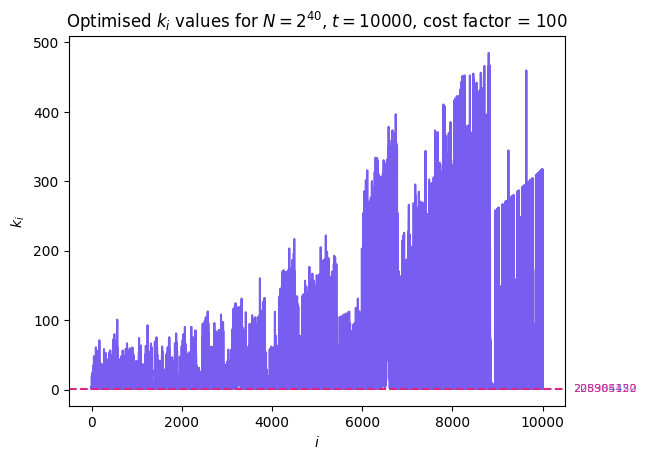

In [60]:
with open('data/N_40_alpha_0.95_cost_5_t_10000_eps_1000000_optimised_kjs.pkl', 'rb') as f:
    result = pickle.load(f)

kjs_ada, m_0_ada, final_cost_ada, m_values_ada = result

try:
    mt, m_vals = approximate_cherry(N, t, alpha, kjs_ada)
    print(f"Success! Approximate cherry m_t for N = 2**40: {mt:.4f}")
except ValueError as e:
    print(f"Error encountered: {e}")

# check that for all items in m_val, the current item is bigger than the next item, if not print the index where this happens
for i in range(len(m_vals)-1):
    if m_vals[i] < m_vals[i+1]:
        print("Index where m_i exceeds m_(i+1):", i)
        break

# plot kjs
plt.plot(kjs_ada, color='#785EF0', label='Optimised $k_i$ values')
plt.xlabel('$i$')
plt.ylabel('$k_i$')

# label mt at the end of the plot, not an arrow, just text
mt = m_values_ada[-1]
y = kjs_ada[-1]
print("Optimised m_t for t=10000:", mt)

plt.annotate(round(mt),
             xy = (len(kjs_ada)+500, y),   # place text outside box in line with end of curve
             xytext = (6, 0),
             color = '#785EF0',
             textcoords = 'offset points',
             size=8,
             va='center')

# plot vanilla m_t as a horizontal line at y=1
vanilla_mt = calculate_vanilla_mt_formula(N, t, alpha)
print("Vanilla m_t for t=10000:", vanilla_mt)
plt.axhline(y=1, color='#DC267F', linestyle='--', label='Vanilla cherry-picks')

# annotate vanilla m_t line
plt.annotate(round(vanilla_mt),
             xy = (len(kjs_ada)+500, 1),   # place text outside box in line with end of curve
             xytext = (6, 0),
             color = '#DC267F',
             textcoords = 'offset points',
             size=8,
             va='center')

plt.title('Optimised $k_i$ values for $N=2^{40}$, $t=10000$, cost factor = 100')
plt.show()

## eps = 1
209021763.2836

Success! Approximate cherry m_t for N = 2**40: 209021763.2836
Optimised m_t for t=10000: 212081106.4741211
Vanilla m_t for t=10000: 208905120.2262377


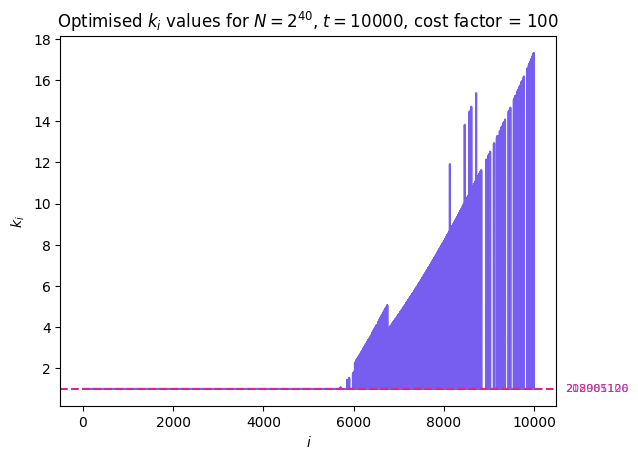

In [61]:
with open('data/N_40_alpha_0.95_cost_5_t_10000_optimised_kjs.pkl', 'rb') as f:
    result = pickle.load(f)

kjs_ada, m_0_ada, final_cost_ada, m_values_ada = result

try:
    mt, m_vals = approximate_cherry(N, t, alpha, kjs_ada)
    print(f"Success! Approximate cherry m_t for N = 2**40: {mt:.4f}")
except ValueError as e:
    print(f"Error encountered: {e}")

# check that for all items in m_val, the current item is bigger than the next item, if not print the index where this happens
for i in range(len(m_vals)-1):
    if m_vals[i] < m_vals[i+1]:
        print("Index where m_i exceeds m_(i+1):", i)
        break

# plot kjs
plt.plot(kjs_ada, color='#785EF0', label='Optimised $k_i$ values')
plt.xlabel('$i$')
plt.ylabel('$k_i$')

# label mt at the end of the plot, not an arrow, just text
mt = m_values_ada[-1]
y = kjs_ada[-1]
print("Optimised m_t for t=10000:", mt)

plt.annotate(round(mt),
             xy = (len(kjs_ada)+500, y),   # place text outside box in line with end of curve
             xytext = (6, 0),
             color = '#785EF0',
             textcoords = 'offset points',
             size=8,
             va='center')

# plot vanilla m_t as a horizontal line at y=1
vanilla_mt = calculate_vanilla_mt_formula(N, t, alpha)
print("Vanilla m_t for t=10000:", vanilla_mt)
plt.axhline(y=1, color='#DC267F', linestyle='--', label='Vanilla cherry-picks')

# annotate vanilla m_t line
plt.annotate(round(vanilla_mt),
             xy = (len(kjs_ada)+500, 1),   # place text outside box in line with end of curve
             xytext = (6, 0),
             color = '#DC267F',
             textcoords = 'offset points',
             size=8,
             va='center')

plt.title('Optimised $k_i$ values for $N=2^{40}$, $t=10000$, cost factor = 100')
plt.show()

Success! Approximate cherry m_t for N = 2**40: 210280999.8911
Optimised m_t for t=10000: 233905588.72277832
Vanilla m_t for t=10000: 208905120.2262377


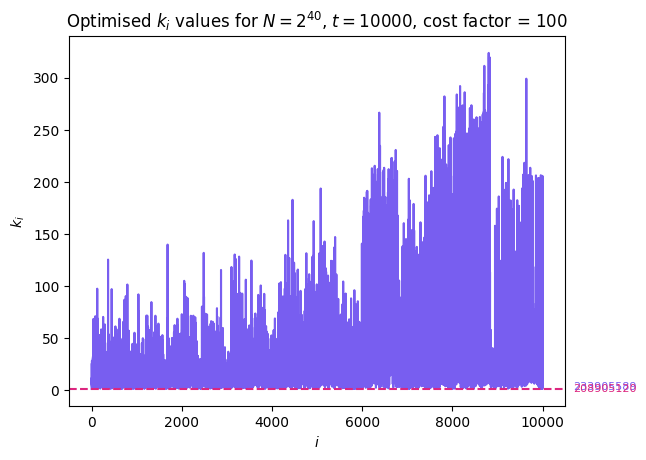

In [63]:
with open('data/N_40_alpha_0.95_cost_5_t_10000_eps_1000000_ftol_1e-12_optimised_kjs.pkl', 'rb') as f:
    result = pickle.load(f)

kjs_ada, m_0_ada, final_cost_ada, m_values_ada = result

try:
    mt, m_vals = approximate_cherry(N, t, alpha, kjs_ada)
    print(f"Success! Approximate cherry m_t for N = 2**40: {mt:.4f}")
except ValueError as e:
    print(f"Error encountered: {e}")

# check that for all items in m_val, the current item is bigger than the next item, if not print the index where this happens
for i in range(len(m_vals)-1):
    if m_vals[i] < m_vals[i+1]:
        print("Index where m_i exceeds m_(i+1):", i)
        break

# plot kjs
plt.plot(kjs_ada, color='#785EF0', label='Optimised $k_i$ values')
plt.xlabel('$i$')
plt.ylabel('$k_i$')

# label mt at the end of the plot, not an arrow, just text
mt = m_values_ada[-1]
y = kjs_ada[-1]
print("Optimised m_t for t=10000:", mt)

plt.annotate(round(mt),
             xy = (len(kjs_ada)+500, y),   # place text outside box in line with end of curve
             xytext = (6, 0),
             color = '#785EF0',
             textcoords = 'offset points',
             size=8,
             va='center')

# plot vanilla m_t as a horizontal line at y=1
vanilla_mt = calculate_vanilla_mt_formula(N, t, alpha)
print("Vanilla m_t for t=10000:", vanilla_mt)
plt.axhline(y=1, color='#DC267F', linestyle='--', label='Vanilla cherry-picks')

# annotate vanilla m_t line
plt.annotate(round(vanilla_mt),
             xy = (len(kjs_ada)+500, 1),   # place text outside box in line with end of curve
             xytext = (6, 0),
             color = '#DC267F',
             textcoords = 'offset points',
             size=8,
             va='center')

plt.title('Optimised $k_i$ values for $N=2^{40}$, $t=10000$, cost factor = 100')
plt.show()